### Trabalho 3 - LSTMs

- Aluno: **Lucas Gabriel de Oliveira Costa**
- Matrícula: **2019109482**
- Disciplina: Redes Neurais

## Preparação do Dataset

In [1]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
import kagglehub

path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")
path

'C:\\Users\\lucas\\.cache\\kagglehub\\datasets\\hgultekin\\bbcnewsarchive\\versions\\1'

In [3]:
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()

# Carrega os dados
data = pd.read_csv(f"{path}/bbc-news-data.csv", sep="\t")
data = data[['content', 'category']]
data.head()

,content,category
0,Quarterly profits at US media giant TimeWarne...,business
1,The dollar has hit its highest level against ...,business
2,The owners of embattled Russian oil giant Yuk...,business
3,British Airways has blamed high fuel prices f...,business
4,Shares in UK drinks and food firm Allied Dome...,business


In [4]:
# Embaralha os dados
data = data.sample(frac=1, random_state=42)
data

,content,category
414,"UK house prices dipped slightly in November, ...",business
420,The London Stock Exchange (LSE) is planning t...,business
1644,Number eight Imanol Harinordoquy has been dro...,sport
416,Shares in UK banking group Barclays have rise...,business
1232,Labour and the Conservatives are still teleph...,politics
...,...,...
1638,England captain Jason Robinson has rubbished ...,sport
1095,Middlesbrough mayor Ray Mallon has been draft...,politics
1130,The Lib Dems have appointed a senior figure f...,politics
1294,Sacked MP Howard Flight's local Conservative ...,politics


## Transformando palavras em *word embeddings*

In [5]:
import gensim.downloader

glove = gensim.downloader.load('glove-twitter-50')
glove.most_similar('awesome')

[('amazing', 0.9468819499015808),
 ('great', 0.9075412154197693),
 ('best', 0.8957678079605103),
 ('fantastic', 0.8926318287849426),
 ('fun', 0.878348708152771),
 ('good', 0.8667678236961365),
 ('this', 0.8594507575035095),
 ('nice', 0.8586857318878174),
 ('pretty', 0.8541362285614014),
 ('perfect', 0.853343665599823)]

In [6]:
import re
import torch
import numpy as np
from textwrap import fill

max_seq_length = 100

def preprocessing(text):
    # remove tags html
    text = re.sub(r"<.*?>", "", text)
    # remove valores não alfanuméricos
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    # converte para minusculo
    text = text.lower()
    # separa palavras
    words = text.split()
    # trunca a sequencia em um tamanho máximo
    words = words[:max_seq_length]
    # converte as palavras em word embeddings descartando
    # aquelas que não existem e converte o resultado em um torch.tensor
    embds = torch.tensor(np.array([glove[w] for w in words if w in glove]))
    return embds


text = data['content'].iloc[10]
embds = preprocessing(text)

print("text:\n", fill(text))
print("\nembds.shape:", embds.shape)

text:
  Yukos has said a US bankruptcy court will decide whether to block
Russia's impending auction of its main production arm on Thursday.
The Russian oil firm has filed for bankruptcy protection in the US in
an attempt to halt the forced sale. However, Judge Letitia Clark said
the hearing would continue on Thursday when arguments in the case
would be heard. Russian authorities are due to auction off
Yuganskneftegas on 19 December to pay a huge tax bill sent to Yukos.
Russian prosecutors are forcing the sale of the firm's most lucrative
asset Yuganskneftegas to help pay a $27bn (£14bn) back tax bill, which
they claim is owed by Yukos.  Filing for bankruptcy protection in the
US was "a last resort to preserve the rights of our shareholders,
employees and customers," said Yukos chief executive Steven Theede.
The company added it had opted to take action through American courts
as US bankruptcy law gives worldwide jurisdiction over a debtor
company's property and because it was seeking 

In [7]:
# Aplicando o pré-processamento para todas as linhas do dataset
x = [preprocessing(t) for t in data['content']]

print("Num de amostras:", len(x))
print("Tamanho de uma amostra:", x[-9].shape)

Num de amostras: 2225
Tamanho de uma amostra: torch.Size([97, 50])


In [8]:
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Converte as classes de string para inteiros
encoder = LabelEncoder()
y = encoder.fit_transform(data['category'].to_numpy())
y = y.astype(np.int64)
y = torch.tensor(y)
y

tensor([0, 0, 3,  ..., 2, 2, 1])

In [9]:
# Pegar os nomes das classes
class_names = encoder.classes_
print("Classes:", class_names)

Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']


In [10]:
from torch.nn.utils.rnn import pad_sequence

# Padroniza o tamanho das sequências de embeddings
x_padded = pad_sequence(x, batch_first=True)
x_padded.shape

torch.Size([2225, 100, 50])

In [11]:
x_padded[-9]

tensor([[-0.7710, -0.1217, -0.2104,  ...,  0.5197, -0.7223, -0.0840],
        [-0.4476,  0.0081, -0.1583,  ...,  0.3884, -0.6121, -0.3677],
        [-0.2947,  0.0772, -0.0316,  ..., -0.4668, -0.6816, -0.7655],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

## Divisão do Dataset em Conjuntos de Treino, Validação e Teste

In [12]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Primeiro separa treino (70%) e temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_padded, y,
    test_size=0.3,
    random_state=42,
)

# Depois divide temp em validação (15%) e teste (15%)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,  # metade de 30% → 15%
    random_state=42,
)

# Datasets
train_ds = TensorDataset(x_train, y_train)
val_ds   = TensorDataset(x_val, y_val)
test_ds  = TensorDataset(x_test, y_test)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))


Train size: 1557
Validation size: 334
Test size: 334


## Definição do Modelo

In [ ]:
from torch import nn

class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        hidden_size = 128

        self.lstm = nn.LSTM(
            input_size=50,     # embedding size
            hidden_size=hidden_size,
            bidirectional=False,
            batch_first=True,
        )

        self.dropout = nn.Dropout(p=0.5)

        self.fc = nn.Linear(hidden_size, 5)

    def forward(self, sequence):
        _, (hidden, cell) = self.lstm(sequence)
        # hidden tem shape [seq_length=1, batch_size, hidden_size].
        # O squeeze abaixo remove a primeira dimensão de forma que
        # o shape se torna [batch_size, hidden_size].
        dropped = self.dropout(hidden.squeeze(0))
        prediction = self.fc(dropped)
        return prediction

net = Model()
net(x_padded[:3])

tensor([[ 0.0222,  0.0102, -0.0796,  0.0282, -0.0264],
        [ 0.0466,  0.0149, -0.0964,  0.0493, -0.0422],
        [ 0.0655,  0.0484, -0.0639,  0.0265, -0.0355]],
       grad_fn=<AddmmBackward0>)

## Treinamento e Avaliação

In [14]:
import torch.optim as optim

net = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-4)

history = []
n_epochs = 50

best_val_loss = float("inf")
best_model_state = None

for epoch in range(n_epochs):

    # Treino
    net.train()
    train_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validação
    net.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.append([train_loss, val_loss])

    # Salva o melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = net.state_dict()

    print(f'[{epoch+1:02d}] Train: {train_loss:.4f} | Val: {val_loss:.4f}')

# Restaura o melhor modelo
net.load_state_dict(best_model_state)

print("Finished Training")

[01] Train: 1.6090 | Val: 1.6045
[02] Train: 1.6013 | Val: 1.5969
[03] Train: 1.5957 | Val: 1.5891
[04] Train: 1.5852 | Val: 1.5808
[05] Train: 1.5804 | Val: 1.5711
[06] Train: 1.5716 | Val: 1.5584
[07] Train: 1.5592 | Val: 1.5421
[08] Train: 1.5393 | Val: 1.5122
[09] Train: 1.4890 | Val: 1.3917
[10] Train: 1.3439 | Val: 1.2125
[11] Train: 1.2645 | Val: 1.1600
[12] Train: 1.1826 | Val: 1.0577
[13] Train: 1.1290 | Val: 0.9886
[14] Train: 1.0201 | Val: 0.9225
[15] Train: 0.9703 | Val: 0.9889
[16] Train: 1.0036 | Val: 0.8398
[17] Train: 0.8908 | Val: 0.8065
[18] Train: 0.8409 | Val: 0.7506
[19] Train: 0.8172 | Val: 0.7396
[20] Train: 0.7834 | Val: 0.7245
[21] Train: 0.7676 | Val: 0.6859
[22] Train: 0.9352 | Val: 0.8509
[23] Train: 0.8246 | Val: 0.6897
[24] Train: 0.7151 | Val: 0.6352
[25] Train: 0.6837 | Val: 0.6386
[26] Train: 0.6601 | Val: 0.5921
[27] Train: 0.6434 | Val: 0.6184
[28] Train: 0.6546 | Val: 0.7705
[29] Train: 0.6500 | Val: 0.7117
[30] Train: 0.6531 | Val: 0.5725
[31] Train

In [15]:
net.eval()
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"\nFinal Test Loss: {test_loss:.4f}")


Final Test Loss: 0.4860


## Resultados

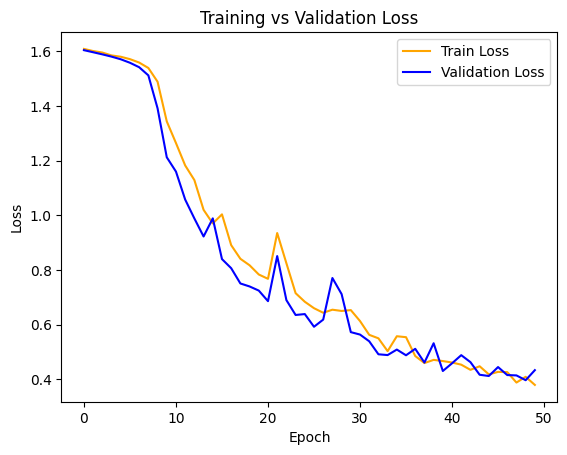

In [16]:
import numpy as np
import matplotlib.pyplot as plt

history = np.array(history)

plt.plot(history[:, 0], '-', color='orange', label='Train Loss')
plt.plot(history[:, 1], '-', color='blue', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import classification_report

def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            cls = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            preds.extend(cls.cpu().numpy())

    return np.array(all_labels), np.array(preds)

all_labels, preds = get_predictions(net, test_loader, device)
print(classification_report(all_labels, preds, target_names=class_names))

               precision    recall  f1-score   support

     business       0.83      0.83      0.83        66
entertainment       0.96      0.81      0.88        64
     politics       0.78      0.82      0.80        60
        sport       0.97      0.87      0.92        77
         tech       0.78      0.96      0.86        67

     accuracy                           0.86       334
    macro avg       0.87      0.86      0.86       334
 weighted avg       0.87      0.86      0.86       334



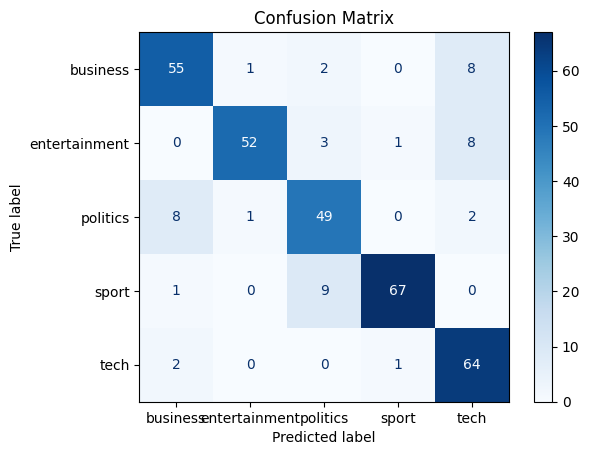

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, preds, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Análise Qualitativa

In [19]:
softmax = torch.nn.Softmax(dim=-1)
net.eval()

def avalia_sentenca(texto, classe_esperada=None):
    embds = preprocessing(texto)

    # functional.pad pads last dims
    # first → for (seq_len, feat_dim) you
    # pad (0,0) on feat dim, then (0, pad_len) on seq dim
    padded = torch.nn.functional.pad(embds, (0, 0, 0, max_seq_length - len(embds)), value=0.0)

    with torch.no_grad():
        padded = torch.unsqueeze(padded, 0)
        padded = padded.to(device)
        
        logits = net(padded)
        probs = softmax(logits)
        
        probs = probs.squeeze().cpu().numpy()
        cls = np.argmax(probs)
        classe_predita = encoder.classes_[cls]

    print(f"Frase: {texto}")
    
    if classe_esperada is not None:
        print(f"Esperada: {classe_esperada}")
    
    print(f"Predita:  {classe_predita}")
    print("-" * 50)

In [20]:
# Business
avalia_sentenca(
    "The company reported a strong increase in quarterly profits after expanding into new international markets.",
    "business"
)
avalia_sentenca(
    "Investors are concerned that rising inflation may reduce consumer spending over the next year.",
    "business"
)

# Entertainment
avalia_sentenca(
    "The actor received critical acclaim after delivering a powerful performance in the new drama film.",
    "entertainment"
)
avalia_sentenca(
    "The singer released a new album that quickly climbed the streaming charts worldwide.",
    "entertainment"
)

# Politics
avalia_sentenca(
    "The president introduced a controversial reform aimed at restructuring the national healthcare system.",
    "politics"
)
avalia_sentenca(
    "Lawmakers debated the proposed legislation before voting on the final amendment.",
    "politics"
)

# Sport
avalia_sentenca(
    "The team secured an important victory after scoring twice in the final minutes of the match.",
    "sport"
)
avalia_sentenca(
    "The striker delivered an outstanding performance and scored the decisive goal in the semifinal.",
    "sport"
)

# Tech
avalia_sentenca(
    "The technology company launched a new artificial intelligence platform focused on data security.",
    "tech"
)
avalia_sentenca(
    "Researchers developed an advanced quantum computing prototype capable of solving complex simulations.",
    "tech"
)

Frase: The company reported a strong increase in quarterly profits after expanding into new international markets.
Esperada: business
Predita:  business
--------------------------------------------------
Frase: Investors are concerned that rising inflation may reduce consumer spending over the next year.
Esperada: business
Predita:  business
--------------------------------------------------
Frase: The actor received critical acclaim after delivering a powerful performance in the new drama film.
Esperada: entertainment
Predita:  business
--------------------------------------------------
Frase: The singer released a new album that quickly climbed the streaming charts worldwide.
Esperada: entertainment
Predita:  business
--------------------------------------------------
Frase: The president introduced a controversial reform aimed at restructuring the national healthcare system.
Esperada: politics
Predita:  business
--------------------------------------------------
Frase: Lawmakers deb

## Conclusão

Os resultados numéricos mostram que o modelo realmente aprendeu ao longo do treinamento, pois tanto o erro de treino quanto o de validação diminuíram de forma semelhante, sem indícios claros de que ele apenas tenha decorado os dados (overffiting). A acurácia final de 86% representa um bom desempenho geral, indicando que, no conjunto de teste, a maioria dos textos foi classificada corretamente e de forma relativamente equilibrada entre os temas.

Por outro lado, ao testar com frases novas criadas manualmente, o modelo apresentou limitações, classificando todas as frases criadas como *business*, mesmo quando pertenciam a outros temas. Foram feitas algumas alterações na rede, como ajustes no tamanho das camadas internas, na quantidade de camadas e na taxa de aprendizado, mas os resultados permaneceram parecidos. Isso sugere que o modelo pode estar muito dependente de certos padrões ou palavras específicas aprendidas durante o treinamento, tendo dificuldade quando o texto foge do estilo original da base. Outras mudanças poderiam ser exploradas, como testar diferentes modelos de *word embeddings* e realizar ajustes mais profundos, mas, por limitação de tempo, essas possibilidades não foram investigadas com mais detalhes.